# Benchmarking – Sample Size:

This benchmarking study is supposed to shed light on the behavior of CARVE under varying conditions of sample size in the dataset.

## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [1]:
import multiprocessing
import os

from typing import Dict, List, Tuple, Type

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.utils import check_random_state

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


We import CARVE:

In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters

We set random seeds:

In [5]:
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
RADNDOM_SEED = 42

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

#### 1.2.1) Benchmarking-Helper-Functions:

This function will be used to set the gamma all SpectralClustering estimaros used. We will use the "median heuristic" as outlined by Garreau et al. (2018): https://arxiv.org/abs/1707.07269

In [7]:
def gamma_quantiles(X, qs=(0.05, 0.10, 0.25, 0.50)):
    D2 = pairwise_distances(X, metric='sqeuclidean')
    d2 = D2[np.triu_indices_from(D2, k=1)]
    return [1.0 / (2.0 * np.quantile(d2, q)) for q in qs]

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [8]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, _: int, random_state: int) -> np.ndarray:
    """
    Generates a reference (null) dataset by sampling each feature independently
    from a uniform distribution spanning the observed feature range.

    Args:
        X (np.ndarray): Original dataset.
        _ (int): Placeholder (unused).
        random_state (int): Seed for reproducibility.

    Returns:
        np.ndarray: Null (reference) dataset of same shape as X.
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the Gap Statistic for a clustering solution, comparing observed within-cluster dispersion
    to that expected under a null reference distribution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').
        n_refs (int): Number of reference datasets to generate (default: 10).
        algorithm (Type[ClusterMixin]): Clustering algorithm used for reference clustering (default: KMeans).
        random_state (str or None): Random seed for reproducibility.

    Returns:
        float: Computed Gap Statistic value for the given clustering configuration.
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, i, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k)
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into `1 / (1 + db)`, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [9]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

`calculate_metric` and `parse_difficulty_and_simulate` are helper functions used to evaluate clustering quality and generate simulated datasets at specified difficulty levels.  
They are designed to support benchmarking of clustering pipelines across a continuum from easy, medium, to difficult settings.

##### Function 1: `calculate_metric`
Dispatches to a chosen clustering validation metric.

**Inputs**
- `X` (`np.ndarray`): Data matrix (samples × features).
- `labels` (`np.ndarray`): Cluster assignments for each sample.
- `metric` (`str`): Which metric to compute. Supported:
  - `'gap'`: Gap Statistic, via `gap_statistic(...)`.
  - `'silhouette'`: Silhouette score, via `silhouette_score(...)`.
  - `'davies_bouldin'`: inverse Davies-Bouldin criterion, via `davies_bouldin_inv(...)`.
  - `'calinski_harabasz'`: Calinski-Harabasz criterion, via `calinski_harabasz_score(...)`.
- `model` (`Type[ClusterMixin]`): Clustering estimator class (used by the Gap Statistic to re-cluster reference datasets).

**Process**
- If `metric == 'gap'`, calls `gap_statistic(X, labels, algorithm=model)`.
- If `metric == 'silhouette'`, calls `silhouette_score(X, labels)`.
- If `metric == 'davies_bouldin'` or `metric == 'DB'`, calls `davies_bouldin_inv(X, labels)`.
- If `metric == 'calinski_harabasz'` or `metric == 'CH'`, calls `calinski_harabasz_score(X, labels)`.
- Otherwise raises `ValueError`.

**Output**
- Returns a single `float` with the requested metric.

##### Function 2: `parse_difficulty_and_simulate`
Builds a simulated dataset `(X, y)` for a given difficulty index by either selecting predefined settings (`easy`, `medium`, `difficult`) or linearly interpolating between them.

**Inputs**
- `settings_by_k` (`Dict[int, Dict[str, List[float]]]`):  
  A dictionary of parameter presets keyed by difficulty level names (`'easy'`, `'medium'`, `'difficult'`).  
  Each difficulty maps parameter names → lists/floats used by `simulate_clusters(...)`.
- `other_settings` (`Dict`):  
  Global defaults/overrides (e.g., `n_total`, `p`, or other simulation knobs). Keys `n_total` and `p` are treated specially.
- `n_datasets` (`int`):  
  Total number of difficulty grid points. Indices are interpreted as:
  - `0` → `'easy'`
  - `int(round(n_datasets // 2))` → `'medium'`
  - `n_datasets - 1` → `'difficult'`
- `difficulty` (`int`):  
  The index in `[0, ..., n_datasets - 1]` selecting or interpolating difficulty.
- `true_k` (`int`):  
  True number of clusters for simulation.
- `random_state` (`int`):  
  RNG seed for reproducibility.

**Process**
1. **Difficulty selection vs interpolation**
   - If `difficulty` is exactly one of the anchor indices (`0`, middle, or last), select that level’s settings directly.
   - If `0 < difficulty < middle`, linearly interpolate easy and medium parameters by fraction `frac = difficulty / middle`.
   - If `middle < difficulty < last`, linearly interpolate medium and difficult by fraction `frac = (difficulty - middle) / (last - middle)`.
   - If outside these regimes, raise `ValueError`.

2. **Parameter resolution**
   - Extract `p` and `n_total` from the chosen/interpolated settings if present; otherwise fall back to `other_settings` defaults (`p=10`, `n_total=500`). This is used for the benchmarking of different sample sizes and dimensionalities.
   - For the settings passed into `simulate_clusters(...)`, include all keys except `['n_total', 'p']`.  
     From `other_settings`, include all keys except `['n_total', 'p', 'balanced', 'plotting']` to avoid collisions and plotting side effects.

3. **Simulation**
   - Call `simulate_clusters(n_total=n_total, p=p, k=true_k, random_state=random_state, plotting=False, **resolved_settings)`.

**Output**
- Returns `(X, y)`:
  - `X` (`np.ndarray`): Simulated feature matrix.
  - `y` (`np.ndarray`): Ground-truth cluster labels.


In [10]:
def calculate_metric(X: np.ndarray, labels: np.ndarray, metric: str, model: Type[ClusterMixin]) -> float:
    """
    Calculates a clustering validation metric for a given clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Metric to compute ('gap', 'silhouette', 'davies_bouldin', 'DB', 'calinski_harabasz', 'CH').
        model (Type[ClusterMixin]): Clustering estimator class (used for Gap Statistic reference clustering).

    Returns:
        float: Value of the requested clustering metric.
    """
    if metric == 'gap':
        return gap_statistic(X, labels, algorithm=model)

    elif metric == 'silhouette':
        return silhouette_score(X, labels)

    elif metric == 'davies_bouldin' or metric == 'DB':
        return davies_bouldin_inv(X, labels)

    elif metric == 'calinski_harabasz' or metric == 'CH':
        return calinski_harabasz_score(X, labels)
    
    else:
        raise ValueError(f"Unknown metric: {metric}")
    
def parse_difficulty_and_simulate(
    settings_by_k: Dict[int, Dict[str, List[float]]],
    other_settings: Dict,
    n_datasets: int,
    difficulty: int,
    true_k: int,
    random_state: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulates clustered datasets based on difficulty level by interpolating settings.

    Args:
        settings_by_k (Dict[int, Dict[str, List[float]]]): Dictionary mapping difficulty levels to simulation settings.
        other_settings (Dict): Additional simulation settings.
        n_datasets (int): Total number of difficulty levels/datasets.
        difficulty (int): Difficulty index (0=easy, middle=medium, last=difficult).
        true_k (int): True number of clusters to simulate.
        random_state (int): Random seed for reproducibility.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Simulated data matrix X and cluster labels y.
    """
    if difficulty == 0 or difficulty == n_datasets - 1 or difficulty == int(round(n_datasets // 2)):
        if difficulty == 0:
            level = 'easy'
        elif difficulty == n_datasets - 1:
            level = 'difficult'
        elif difficulty == int(round(n_datasets // 2)):
            level = 'medium'
            
        if 'p' in settings_by_k[level]:
            p = int(np.floor(settings_by_k[level]['p'] + 0.5))
        else:
            p = other_settings.get('p', 10)
        
        if 'n_total' in settings_by_k[level]:
            n_total = int(np.floor(settings_by_k[level]['n_total'] + 0.5))
        else:
            n_total = other_settings.get('n_total', 500)
            
        X, y, _ = simulate_clusters(
            n_total=n_total,
            p=p,
            k=true_k,
            plotting=False,
            random_state=random_state,
            **{k: v for k, v in settings_by_k[level].items() if k not in ['n_total', 'p']},
            **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'balanced', 'plotting']}
        )
        
    else:
        if difficulty > 0 and difficulty < int(round(n_datasets // 2)):
            # Linear interpolation between 'easy' and 'medium' settings
            frac = difficulty / int(round(n_datasets // 2))
            easy_settings = settings_by_k['easy']
            medium_settings = settings_by_k['medium']
            interpolated_settings = {}
            for key in easy_settings:
                v_easy = np.array(easy_settings[key])
                v_medium = np.array(medium_settings[key])
                interpolated = (1 - frac) * v_easy + frac * v_medium
                interpolated_settings[key] = interpolated.tolist()
                
        elif difficulty > int(round(n_datasets // 2)) and difficulty < (n_datasets - 1):
            # Linear interpolation between 'medium' and 'difficult' settings
            frac = (difficulty - int(round(n_datasets // 2))) / (n_datasets - 1 - int(round(n_datasets // 2)))
            medium_settings = settings_by_k['medium']
            difficult_settings = settings_by_k['difficult']
            interpolated_settings = {}
            for key in medium_settings:
                v_medium = np.array(medium_settings[key])
                v_difficult = np.array(difficult_settings[key])
                interpolated = (1 - frac) * v_medium + frac * v_difficult
                interpolated_settings[key] = interpolated.tolist()
                
        else:
            raise ValueError(f"Got difficulty={difficulty} but expected 0, {n_datasets - 1}, {int(round(n_datasets // 2))}, or a value in between those.")
        
        if 'p' in interpolated_settings:
            p = int(np.floor(interpolated_settings['p'] + 0.5))
        else:
            p = other_settings.get('p', 10)
        
        if 'n_total' in interpolated_settings:
            n_total = int(np.floor(interpolated_settings['n_total'] + 0.5))
        else:
            n_total = other_settings.get('n_total', 500)
            
        X, y, _ = simulate_clusters(
            n_total=n_total,
            p=p,
            k=true_k,
            plotting=False,
            random_state=random_state,
            **{k: v for k, v in interpolated_settings.items() if k not in ['n_total', 'p']},
            **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'balanced', 'plotting']}
        )
    
    return X, y

`benchmark_cluster_metrics` runs a large-scale benchmarking loop to compare clustering selection criteria across simulated datasets of varying difficulty. For each synthetic dataset, it evaluates CARVE-based measures and external metrics (e.g., silhouette, gap), records scores over candidate k values, and returns a results table.

##### Inputs
- `settings_by_k`: dict mapping true_k to difficulty presets used by `parse_difficulty_and_simulate`.
- `other_settings`: global simulation defaults/overrides.
- `n_datasets` (int, default 10): number of difficulty steps (indexed 0 … n_datasets−1).
- `B` (int, default 20): number of dataset replicates per difficulty and true_k.
- `model` (str, default 'kmeans'): base clustering family used to build `model_grids` if none provided. One of {'kmeans', 'agglomerative', 'spectral'}.
- `model_grids` (list or None): list of tuples `(EstimatorClass, param_grid_dict)` describing grids over candidate k and model hyperparameters. If None, a default grid is created based on `model`.
- `true_ks` (list, default [3, 4, 5, 6]): ground-truth numbers of clusters to simulate.
- `test_ks` (iterable, default range(2, 8)): candidate k values to evaluate.
- `external_metrics` (list, default ["silhouette", "gap", "davies_bouldin", "calinski_harabasz"]): additional metrics to maximize over k using `calculate_metric`.
- `random_state` (int, default 42): seed offset for reproducibility.

##### Process
1. Setup
   - Defines the CARVE measures tracked: `ari_stability`, `ari_generalizability`, their 1se rules, and `consensus_pac_stability`.
   - Initializes a progress bar over `n_datasets * B * len(true_ks)` iterations.

2. Data generation
   - For each difficulty index `i` in `[0, …, n_datasets−1]`, each replicate `seed` in `[0, …, B−1]`, and each `true_k` in `true_ks`, calls `parse_difficulty_and_simulate(...)` to obtain `(X, y)` using either anchor settings or linear interpolation between easy/medium/difficult.

3. Model grid construction
   - If `model_grids` is None, constructs a default grid:
     - kmeans: `(KMeans, {"n_clusters": test_ks})`
     - agglomerative: `(AgglomerativeClustering, {"n_clusters": test_ks, "linkage": ["ward"]})`
     - spectral: `(SpectralClustering, {"n_clusters": test_ks, "affinity": ["rbf"], "gamma": [gamma_quantiles(X)[3]]})` (index 3 corresponds to the median heuristic)

4. CARVE validation
   - Builds a `ValidatorConfig(X=X, ref_labels=y, model_grids=model_grids)` and runs `CARVE(cfg).validate(...)`.
   - For each CARVE measure:
     - Selects rule = '1se' if the measure name ends with `_1se`, else 'max'.
     - Derives `measure` by stripping `_1se` when present.
     - Obtains `optimal_k = val.get_optimal_k(measure, rule)`.
     - For every candidate k in `test_ks`, reads the score `value = val.model_df[measure]` at that k and appends a results row.

5. External metrics
   - For each metric in `external_metrics`:
     - For every k in `test_ks`, gets labels via `val.get_optimal_labels(k=k)` and computes the score with `calculate_metric(X, labels, metric, model=model_grids[0][0])`.
     - Picks `optimal_k` as the k maximizing the metric and appends rows for all k with flags set accordingly.

6. Bookkeeping
   - Updates the progress bar each inner loop iteration, closes it at the end.

##### Output
Returns a pandas DataFrame with one row per (difficulty, dataset_id, true_k, k, metric). Columns include:
- `difficulty`: difficulty index i
- `metric_name`: e.g., `ari_stability`, `ari_generalizability_1se`, `consensus_pac_stability`, `silhouette`, `davies_bouldin`
- `true_k`: ground-truth number of clusters
- `k`: candidate number of clusters evaluated
- `metric_value`: score for the metric at this k
- `is_optimal`: whether this k is selected by the metric’s rule within the current dataset
- `is_correct`: whether `k == true_k`
- `dataset_id`: replicate seed


In [11]:
def benchmark_cluster_metrics(
    settings_by_k, 
    other_settings, 
    n_datasets=10,
    B=20,
    model='kmeans',
    model_grids=None,
    true_ks=[3, 4, 5, 6],
    test_ks=range(2, 7+1),
    external_metrics=["silhouette", "gap", "davies_bouldin", "calinski_harabasz"],
    random_state=42
) -> pd.DataFrame:
    """
    Benchmarks clustering metrics across multiple simulated datasets and clustering configurations.

    Args:
        settings_by_k (Dict): Dictionary mapping true number of clusters to simulation settings.
        other_settings (Dict): Additional simulation settings.
        n_datasets (int): Number of datasets to simulate per difficulty level.
        B (int): Number of random seeds per dataset.
        model (str): Clustering model to use ('kmeans', 'agglomerative', 'spectral').
        model_grids (List[Tuple[Type, Dict]], optional): List of model classes and their parameter grids.
        true_ks (List[int]): List of true number of clusters for simulation.
        test_ks (range): Range of cluster numbers to test.
        external_metrics (List[str]): List of external metrics to evaluate.
        random_state (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: DataFrame containing benchmarking results for each metric, dataset, and configuration.
    """
    results = []

    CARVE_AVAILABLE_METRICS = [
        'ari_stability', 'ari_generalizability', 
        'ari_stability_1se', 'ari_generalizability_1se', 
        'consensus_pac_stability'
    ]

    total_steps = n_datasets * B * len(true_ks)
    pbar = tqdm(total=total_steps, desc="Benchmarking", leave=True)
    for i in range(n_datasets):
        for seed in range(B):
            for true_k in true_ks:
                X, y = parse_difficulty_and_simulate(
                    settings_by_k=settings_by_k[true_k],
                    other_settings=other_settings,
                    n_datasets=n_datasets,
                    difficulty=i,
                    true_k=true_k,
                    random_state=seed
                )
                
                # fit and evaluate CARVE
                if model_grids is None:
                    if model == 'agglomerative':
                        model_grids = [
                            (AgglomerativeClustering, {"n_clusters": test_ks, "linkage": ["ward"]})
                        ]
                        
                    elif model == 'spectral':
                        model_grids = [
                            (SpectralClustering, {"n_clusters": test_ks, "affinity": ["rbf"], "gamma": [gamma_quantiles(X)[3]]})
                        ]
                        
                    else:  # default to KMeans
                        model_grids = [
                            (KMeans, {"n_clusters": test_ks})
                        ]

                cfg = ValidatorConfig(
                    X=X,
                    ref_labels=y,
                    model_grids=model_grids
                )

                val = CARVE(cfg)
                val.validate(prog_bar=False, random_state=seed+random_state)
                
                for carve_metric in CARVE_AVAILABLE_METRICS:
                    rule = '1se' if carve_metric.endswith('_1se') else 'max'
                    
                    if carve_metric.endswith('_1se'):
                        measure = carve_metric[:-4]
                    else:
                        measure = carve_metric
                            
                    optimal_k = val.get_optimal_k(measure=measure, rule=rule)
                    
                    for k in test_ks:
                        value = val.model_df[measure].loc[val.model_df['n_clusters'] == k].values[0]
                        results.append({
                            'difficulty': i,
                            'metric_name': carve_metric,
                            'true_k': true_k,
                            'k': k,
                            'metric_value': value,
                            'is_optimal': k == optimal_k,
                            'is_correct': k == true_k,
                            'dataset_id': seed
                        })
                
                # evaluate external metrics
                for metric in external_metrics:
                    metric_values = []
                    
                    # Calculate metric value for each test_k
                    for k in test_ks:
                        labels = val.get_optimal_labels(k=k)
                        value = calculate_metric(X, labels, metric, model=model_grids[0][0])
                        metric_values.append((k, value))
                    
                    # Find the k where respective metric is maximized
                    optimal_k, _ = max(metric_values, key=lambda x: x[1])
                    
                    # Record all results
                    for k, value in metric_values:
                        results.append({
                            'difficulty': i,
                            'metric_name': metric,
                            'true_k': true_k,
                            'k': k,
                            'metric_value': value,
                            'is_optimal': k == optimal_k,
                            'is_correct': k == true_k,
                            'dataset_id': seed
                        })

                pbar.update(1)
    
    pbar.close()
    return pd.DataFrame(results)

#### 1.2.2) Plotting-Helper-Functions:

`plot_examples` visualizes example clustering datasets across varying levels of difficulty and cluster counts, while also computing a baseline clustering performance metric (Adjusted Rand Index, ARI) for each configuration.

##### Purpose
`plot_examples` generates side-by-side scatter plots (via PCA projection) of simulated datasets for different:
- numbers of clusters `k`, and  
- difficulty anchors (`easy`, `medium`, `difficult`).

It is designed to qualitatively and quantitatively illustrate how clustering difficulty and dimensionality influence baseline clustering performance.

##### Inputs
- **`settings_by_k` (`Dict`)**  
  Configuration dictionary that defines simulation parameters for each `k` (number of clusters) and difficulty level (anchor).

- **`other_settings` (`Dict`)**  
  Global or shared simulation parameters (e.g., total samples `n_total`, dimensions `p`).

- **`ks` (`np.ndarray`, default `[3, 4, 5, 6]`)**  
  Array of cluster counts to test.

- **`anchors` (`List[str]`, default `['easy', 'medium', 'difficult']`)**  
  Levels of dataset difficulty or separability.

- **`B` (`int`, default `10`)**  
  Number of replicate simulations for baseline ARI estimation.

- **`estimator_type` (`str`, default `'hierarchical'`)**  
  Type of clustering algorithm used to compute ARI:  
  `'hierarchical'`: Agglomerative clustering  
  `'spectral'`: Spectral clustering  

- **`name_of_ex` (`str`, default `'Uncorrelated Gaussians'`)**  
  Title used for the overall figure.

##### Process
1. **Grid Setup:**  
   Creates a grid of subplots with one row per `k` and one column per difficulty level.

2. **Parameter Handling:**  
   Retrieves or defaults the number of samples (`n_total`) and feature dimensions (`p`).

3. **Simulation:**  
   Uses a helper function `simulate_clusters(...)` to generate synthetic datasets based on the given parameters.

4. **Baseline ARI Computation:**  
   For each configuration, performs `B` replicate simulations, clustering each simulated dataset and computing the mean ARI as a performance baseline.

5. **Visualization:**  
   - Reduces each dataset to 2D via PCA.
   - Colors points by true cluster labels.
   - Displays the mean ARI in the subplot title.

6. **Layout:**  
   Adds an overall title and formats the plot for clear visual comparison.

##### Output
- No return value.
- Displays a grid of PCA scatter plots showing:
  - Cluster separability across difficulties and `k`.
  - Mean baseline ARI in each title.


In [13]:
def plot_examples(
    settings_by_k: Dict, 
    other_settings: Dict, 
    ks: np.ndarray = np.array([3, 4, 5, 6]), 
    anchors: List[str] = ['easy', 'medium', 'difficult'], 
    B: int = 10, 
    estimator_type: str = 'hierarchical', 
    name_of_ex: str = 'Uncorrelated Gaussians'
) -> None:
    """
    Visualizes example clustering datasets for different cluster counts and difficulty levels,
    and computes baseline clustering performance (ARI) for each configuration.

    Args:
        settings_by_k (Dict): Simulation parameters for each k and difficulty anchor.
        other_settings (Dict): Shared/global simulation parameters.
        ks (np.ndarray): Array of cluster counts to visualize.
        anchors (List[str]): List of difficulty levels.
        B (int): Number of replicates for baseline ARI estimation.
        estimator_type (str): Clustering algorithm type ('hierarchical' or 'spectral').
        name_of_ex (str): Title for the figure.

    Returns:
        None
    """
    
    _, axes = plt.subplots(len(ks), len(anchors), figsize=(12, 14))
    for i, k in enumerate(ks):
        for j, a in enumerate(anchors):
            
            # get n_total and p 
            if 'n_total' in settings_by_k:
                n_total = int(np.floor(settings_by_k['n_total'] + 0.5))
            else:
                n_total = other_settings.get('n_total', 500)
                
            if 'p' in settings_by_k:
                p = int(np.floor(settings_by_k['p'] + 0.5))
            else:
                p = other_settings.get('p', 10)
            
            # simulate dataset to be displayed
            X, y, _ = simulate_clusters(
                n_total=n_total,
                p=p,
                k=k,
                plotting=False,
                random_state=1*10 + j,
                **settings_by_k[k][a],
                **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
            )
            
            # compute baseline ARI over B replicates
            ari_arr = []
            for b in range(B):
                X_val, y_val, _ = simulate_clusters(
                    n_total=n_total,
                    p=p,
                    k=k,
                    plotting=False,
                    random_state=1*100 + j*10 + b,
                    **settings_by_k[k][a],
                    **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
                )
                
                if estimator_type == 'hierarchical':
                    estimator = AgglomerativeClustering(
                        n_clusters=k
                    )
                elif estimator_type == 'spectral':
                    estimator = SpectralClustering(
                        n_clusters=k,
                        assign_labels='discretize',
                        random_state=0
                    )
                else:
                    raise ValueError("estimator_type must be 'hierarchical' or 'spectral'")
                
                y_hat_val = estimator.fit_predict(X_val)
                ari = adjusted_rand_score(y_val, y_hat_val)
                ari_arr.append(ari)
                
            ari_mean = np.mean(ari_arr)

            # plot PCA of dataset
            X_pca = PCA(n_components=2, random_state=0).fit_transform(X)
            ax = axes[i, j]
            ax.scatter(
                X_pca[:, 0], X_pca[:, 1],
                c=y, cmap="tab10", s=20, alpha=0.8, edgecolors="k"
            )
            ax.set_title(f"k={k}, difficulty={a} | Baseline ARI={ari_mean:.3f}")
            ax.set_xticks([]); ax.set_yticks([])
            
    plt.suptitle(f"Example datasets: {name_of_ex}", fontsize=16)
    plt.tight_layout(); plt.show()

`plot_accuracy_vs_difficulty` plots how often each metric selects the correct number of clusters as difficulty increases. Accuracy is computed per dataset, then summarized across replicates for each difficulty and metric, and finally visualized as mean accuracy curves with optional uncertainty bands.

##### Inputs
- `results_df` (pandas DataFrame): Long-form results with at least the columns  
  `difficulty`, `metric_name`, `dataset_id`, `is_optimal`, `is_correct`.  
  Typically produced by the benchmarking routines.
- `show_se` (bool, default False): If True, shades an uncertainty band around the mean.  
  Note: the band is mean ± standard deviation as computed, not the standard error.

##### What It Computes
1. Filters to rows where `is_optimal` is True (the k chosen by each metric for that dataset).
2. For each `(difficulty, metric_name, dataset_id)`, computes the mean of `is_correct`.  
   This yields an accuracy per dataset replicate.
3. For each `(difficulty, metric_name)`, aggregates replicate accuracies into  
   mean and standard deviation.
4. Produces a line for each `metric_name` showing mean accuracy versus `difficulty`.  
   If `show_se` is True, fills a band using mean ± std.

##### Plot Details
- X-axis: `difficulty` (integer index of problem difficulty).
- Y-axis: mean accuracy (fraction of datasets where the metric picked the true k).
- Lines: one per `metric_name`, with circular markers.
- Optional shaded area: mean ± std across `dataset_id` replicates (when `show_se=True`).
- Grid and legend included for readability.

##### Output
- Returns nothing. Displays a Matplotlib figure with accuracy curves by metric.


In [14]:
def plot_accuracy_vs_difficulty(
    results_df: pd.DataFrame, 
    show_se: bool = False
) -> None:
    """
    Plots the accuracy of clustering metrics as a function of problem difficulty.

    Args:
        results_df (pd.DataFrame): DataFrame containing benchmarking results with columns
            ['difficulty', 'metric_name', 'is_optimal', 'is_correct', 'dataset_id'].
        show_se (bool, optional): If True, displays standard error bands around the mean accuracy.

    Returns:
        None. Displays a line plot of accuracy vs. difficulty for each metric.
    """
    accuracy_df = (
        results_df[results_df['is_optimal']]
        .groupby(['difficulty', 'metric_name', 'dataset_id'])
        .agg({'is_correct': 'mean'})
        .reset_index()
        .groupby(['difficulty', 'metric_name'])
        .agg({'is_correct': ['mean', 'std']})
        .reset_index()
    )
    
    # Plot
    plt.figure(figsize=(12, 8))
    for metric in accuracy_df['metric_name'].unique():
        subset = accuracy_df[accuracy_df['metric_name'] == metric]
        plt.plot(subset['difficulty'], subset[('is_correct', 'mean')], marker='o', label=metric)
        if show_se:
            plt.fill_between(
                subset['difficulty'],
                subset[('is_correct', 'mean')] - subset[('is_correct', 'std')],
                subset[('is_correct', 'mean')] + subset[('is_correct', 'std')],
                alpha=0.2
        )
    
    plt.xlabel('Difficulty (difficulty)')
    plt.ylabel('Accuracy')
    plt.title('Metric Accuracy vs. Problem Difficulty')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

`plot_metric_lineplots_grid` builds a grid of line plots that summarize metric values across candidate k for selected difficulty anchors and true_k rows. Each subplot shows the mean metric value vs k for several metrics, with optional majority-vote markers that indicate which k a metric most often selects under two rules (max and 1se), including an agreement marker when both rules pick the same k.

##### Inputs
- `results_df` (DataFrame): Long results table with columns including `true_k`, `k`, `difficulty`, `metric_name`, `metric_value`, and optionally `is_optimal`.
- `difficulties` (list-like): Ordered list of difficulty indices; the first, middle, and last are used as anchors.
- `metrics_to_display` (list or None): Optional filter of metric names to plot. Metrics ending with `_1se` are excluded from the lines (their votes are shown via markers).
- `show_majority_votes` (bool, default True): If True, overlays vote markers for max and 1se rules and an agreement star when both rules pick the same k.
- `figsize` (tuple or None): Figure size `(width, height)`. Defaults to `(3.5 * num_anchors, 2.5 * num_true_k)`.

##### What It Plots
- Rows correspond to `true_k` values found in `results_df`.
- Columns correspond to difficulty anchors: first, middle, and last of `difficulties`.
- For each subplot:
  - For each base metric (not ending in `_1se`), plots the mean of `metric_value` vs `k`, with circular markers.
  - Optionally overlays vote markers:
    - Diamond at the k chosen most often by the base metric under the max rule (ties break to the largest k).
    - X at the k chosen most often by the paired `_1se` variant under the 1se rule (ties break to the largest k).
    - Star above the curve if both rules choose the same k (agreement).

##### Special Handling of Paired Metrics
- The function treats these pairs as related:
  - `ari_stability` with `ari_stability_1se`
  - `ari_generalizability` with `ari_generalizability_1se`
- Lines are drawn only for the base metrics (`ari_stability`, `ari_generalizability`), while vote markers can appear for both the base and the `_1se` partner.
- The agreement star is shown only when both rules select the same k.

##### Data Processing Details
- Casts `is_optimal` to int when present (numeric safety).
- Uses a tolerance-based mask to match continuous `difficulty` values to chosen anchors.
- Averages `metric_value` over replicates at each `(true_k, difficulty, k, metric_name)` to produce the line curves.
- Majority votes are computed by summing `is_optimal` within `(true_k, difficulty, metric_name, k)` and taking the k with the highest count; ties resolve to the largest k.

##### Axes, Labels, and Guides
- Vertical dashed guide at the row’s `true_k`.
- Column titles show `alpha = <difficulty>` using the numeric difficulty at that column.
- Y-axis label per row: `true_k = <value>`. X-axis label: `k`.
- X-limits expand to cover the observed min and max k with a small margin.
- Grid lines and a shared legend are included. The legend includes:
  - Line labels for each base metric.
  - Optional markers for vote annotations: diamond (max rule), x (1se rule), star (agreement).

##### Output
- Returns nothing. Displays a Matplotlib figure with a grid of line plots, one column per difficulty anchor and one row per true_k.


In [15]:
def plot_metric_lineplots_grid(
    results_df: pd.DataFrame,
    difficulties: List[float],
    metrics_to_display: List[str] = None,
    show_majority_votes: bool = True,
    figsize: Tuple[float, float] = None
) -> None:
    """
    Plots a grid of line plots for clustering metrics across different difficulties and true_k values.

    Args:
        results_df (pd.DataFrame): DataFrame containing clustering results with columns:
            ['true_k', 'k', 'difficulty', 'metric_name', 'metric_value', ...].
        difficulties (List[float]): List of difficulty values to anchor the grid columns.
        metrics_to_display (Optional[List[str]]): List of metric names to plot. If None, all available metrics are used.
        show_majority_votes (bool): If True, displays majority vote markers (diamond, star, cross) for optimal k selection.
        figsize (Optional[Tuple[float, float]]): Figure size for the plot. If None, size is determined automatically.

    Returns:
        None. Displays the matplotlib figure.
    """
    PAIRED = {
        "ari_stability_1se": "ari_stability",
        "ari_generalizability_1se": "ari_generalizability",
    }
    
    BASE_WITH_PAIR = set(PAIRED.values())  # metrics that have a 1se partner

    # numeric safety
    results_df = results_df.copy()
    if 'is_optimal' in results_df.columns:
        results_df['is_optimal'] = results_df['is_optimal'].astype(int)

    anchors = [difficulties[0], difficulties[len(difficulties)//2], difficulties[-1]]

    all_metrics = sorted(results_df['metric_name'].unique())
    if metrics_to_display is not None:
        metrics = [m for m in metrics_to_display if (m in all_metrics) and (m not in PAIRED.keys())]
        if not metrics:
            raise ValueError(f"None of the provided metrics {metrics_to_display} found in data")
    else:
        metrics = [m for m in all_metrics if m not in PAIRED.keys()]

    true_ks = sorted(results_df['true_k'].unique())

    if figsize is None:
        figsize = (3.5*len(anchors), 2.5*len(true_ks))

    fig, axes = plt.subplots(len(true_ks), len(anchors), figsize=figsize)

    if len(true_ks) == 1:
        axes = np.array([axes])
    if len(anchors) == 1:
        axes = np.array([axes]).T

    def difficulty_mask(series, a):
        return np.isclose(series.to_numpy(dtype=float), float(a), rtol=1e-6, atol=1e-8)

    for i, true_k in enumerate(true_ks):
        for j, difficulty in enumerate(anchors):
            ax = axes[i, j]
            line_y = {}

            # plot each (base) metric line
            for metric in metrics:
                subset_mask = (
                    (results_df['true_k'] == true_k) &
                    (results_df['metric_name'] == metric) &
                    difficulty_mask(results_df['difficulty'], difficulty)
                )
                subset = results_df.loc[subset_mask]
                if subset.empty:
                    continue

                avg_df = (
                    subset.groupby('k')['metric_value']
                        .agg(mean='mean', std='std')
                        .reset_index()
                )
                mean_values = avg_df['mean'].to_numpy()

                ax.plot(avg_df['k'], mean_values, marker='o', label=metric)
                line_y[metric] = dict(zip(avg_df['k'].to_numpy(), mean_values))

                if show_majority_votes and 'is_optimal' in subset.columns and metric not in BASE_WITH_PAIR:
                    votes = subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    if not votes.empty:
                        k_base_vote = int(votes[votes == votes.iloc[0]].index.max())  # if tie, then largest k
                        if k_base_vote in line_y[metric]:
                            y_on_curve = float(line_y[metric][k_base_vote])
                            ax.scatter(
                                [k_base_vote], [y_on_curve], marker='D', s=70,
                                edgecolors='black', facecolors='white',
                                zorder=5, label=None
                            )

            # handle paired markers with agreement logic
            if show_majority_votes:
                for excl_metric, base_metric in PAIRED.items():
                    excl_mask = (
                        (results_df['true_k'] == true_k) &
                        (results_df['metric_name'] == excl_metric) &
                        difficulty_mask(results_df['difficulty'], difficulty)
                    )
                    base_mask = (
                        (results_df['true_k'] == true_k) &
                        (results_df['metric_name'] == base_metric) &
                        difficulty_mask(results_df['difficulty'], difficulty)
                    )
                    excl_subset = results_df.loc[excl_mask]
                    base_subset = results_df.loc[base_mask]
                    if excl_subset.empty or base_subset.empty:
                        continue
                    if 'is_optimal' not in excl_subset.columns or 'is_optimal' not in base_subset.columns:
                        continue

                    # votes (consistent tie rule: largest k)
                    excl_votes = excl_subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    base_votes = base_subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    if excl_votes.empty or base_votes.empty:
                        continue

                    k_excl_vote = int(excl_votes[excl_votes == excl_votes.iloc[0]].index.max())
                    k_base_vote = int(base_votes[base_votes == base_votes.iloc[0]].index.max())

                    # y anchors from the base metric curve
                    y_map = line_y.get(base_metric, {})
                    if not y_map:
                        continue
                    # require the y for at least the locations we will plot
                    if (k_base_vote not in y_map) and (k_excl_vote not in y_map):
                        continue

                    if k_base_vote == k_excl_vote:
                        y_star = float(y_map.get(k_base_vote, list(y_map.values())[0]))
                        y_star += 0.02
                        ax.scatter([k_base_vote], [y_star], marker='*', s=220,
                                   facecolors='none', edgecolors='black',
                                   linewidths=2.0, zorder=8, label=None)
                    else:
                        # draw ◇ at base vote
                        if k_base_vote in y_map:
                            y_d = float(y_map[k_base_vote])
                            ax.scatter(
                                [k_base_vote], [y_d], marker='D', s=70,
                                edgecolors='black', facecolors='white',
                                zorder=6, label=None
                            )

                        if k_excl_vote in y_map:
                            y_x = float(y_map[k_excl_vote]) + 0.025
                            ax.scatter(
                                [k_excl_vote], [y_x], marker='x', s=90,
                                color='black', linewidths=2, zorder=7, label=None
                            )

            # guides / labels
            ax.axvline(true_k, color='gray', linestyle='--', alpha=0.5)
            if i == 0:
                ax.set_title(f'α = {difficulty:.3f}')
            if j == 0:
                ax.set_ylabel(f'true_k = {true_k}')
            ax.set_xlabel('k')
            ax.grid(True, alpha=0.3)

            k_values = results_df['k'].unique()
            ax.set_xlim(min(k_values) - 0.5, max(k_values) + 0.5)

    # legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if show_majority_votes:
        handles += [
            Line2D(
                [0],[0], marker='D', linestyle='None',
                markerfacecolor='white', markeredgecolor='black', label='max rule (vote)'
            ),
            Line2D(
                [0],[0], marker='x', linestyle='None',
                color='black', label='1se rule (vote)'
            ),
            Line2D(
                [0],[0], marker='*', linestyle='None',
                markerfacecolor='none', markeredgecolor='black', label='agree (vote)'
            ),
        ]
        labels += ['max rule (vote)', '1se rule (vote)', 'agree (vote)']

    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02),
        fancybox=True, shadow=True, ncol=min(5, max(1, len(metrics)))
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

`print_summary_stats` prints a compact accuracy summary for clustering metrics across difficulty levels. It filters to rows where a metric actually selected a k (`is_optimal == True`), computes accuracy per `(difficulty, metric_name)`, marks the best metric per difficulty with a star, and reports an overall ranking aggregated across all difficulties.

##### Inputs
- `results_df` (pandas DataFrame): Benchmark results with columns including  
  `difficulty`, `metric_name`, `is_optimal`, `is_correct`, and optionally others.

##### What It Computes
- Per `(difficulty, metric_name)`:
  - Mean accuracy: average of `is_correct`.
  - Standard deviation of accuracy across dataset replicates.
  - Count of contributing rows.
- A star marker for the metric with the highest mean accuracy within each difficulty (ties resolved by groupby idxmax semantics).
- An overall summary across all difficulties:
  - Mean accuracy and standard deviation for each `metric_name`.
  - A descending ranking by mean accuracy.

##### Process
1. Filter to `is_optimal == True` so that each metric contributes only where it made a selection for that dataset.
2. Group by `(difficulty, metric_name)` and compute mean, std, and count on `is_correct`.
3. Identify the per-difficulty winner and tag it with `*`.
4. Format a string cell per metric and difficulty as `mean+/-std` with the star appended when applicable.
5. Pivot to a grid with metrics as rows and difficulty values as columns for readable printing.
6. Compute an overall table by aggregating across all difficulties, then sort for a ranked list.

##### Printed Report
1. Header: `Accuracy (mean+/-std)`  
   - A string grid where each cell is `mean+/-std` (e.g., `0.812+/-0.045`) and, for difficulty winners, `0.845+/-0.030*`.
2. Header: `Overall ranking (aggregated over all difficulties and k)`  
   - A numbered list of metrics with `mean +/- std` and sample size `n`.

##### Output
- Returns nothing. Writes the formatted tables to standard output for quick inspection and comparison of metric performance.


In [16]:
def print_summary_stats(results_df: pd.DataFrame) -> None:
    """
    Prints a summary table of clustering metric accuracy statistics.

    Args:
        results_df (pd.DataFrame): DataFrame containing benchmarking results with columns
            ['difficulty', 'metric_name', 'is_optimal', 'is_correct', ...].

    Returns:
        None. Displays formatted accuracy statistics per metric and difficulty, and overall ranking.
    """
    df = results_df.loc[results_df['is_optimal']].copy()

    # --- per-(difficulty, metric) stats
    g = (
        df.groupby(['difficulty', 'metric_name'])['is_correct']
            .agg(mean='mean', std='std', n='count')
            .reset_index()
    )
    g['std'] = g['std'].fillna(0.0)

    difficulties = sorted(g['difficulty'].unique())

    # --- star best per difficulty
    stars = (
        g.loc[g.groupby('difficulty')['mean'].idxmax(), ['difficulty', 'metric_name']]
            .set_index(['difficulty', 'metric_name'])
            .assign(star='*')
    )

    # helper to format "m ± s" and add star
    def _fmt(row):
        key = (row['difficulty'], row['metric_name'])
        star = stars.loc[key, 'star'] if key in stars.index else ''
        return f"{row['mean']:.3f}±{row['std']:.3f}{star}"

    g['cell'] = g.apply(_fmt, axis=1)

    # --- pretty grid (string view)
    grid = (
        g.pivot(index='metric_name', columns='difficulty', values='cell')
            .reindex(columns=difficulties)
    )

    # # --- overall across all alpha & k
    overall = (
        df.groupby('metric_name')['is_correct']
            .agg(mean='mean', std='std', n='count')
    )
    overall['std'] = overall['std'].fillna(0.0)

    # print 
    print("\n=== Accuracy (mean±std)")
    # align columns by width
    with pd.option_context('display.max_columns', None, 'display.width', 160):
        print(grid.fillna('').sort_index())

    # overall ranking block
    print("\n=== Overall ranking (aggregated over all α & k) ===")
    ranked = overall.sort_values('mean', ascending=False)
    for i, (metric, r) in enumerate(ranked.iterrows(), start=1):
        print(f"{i:>2}. {metric:<20} {r['mean']:.3f} ± {r['std']:.3f}  (n={int(r['n'])})")


---

### 2.1 Sample Size Benchmark:

In [ ]:
settings_by_k_gausN = {
    3: {
        'easy':    {"cluster_scale": [5] * 3, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 500},
        'medium':  {"cluster_scale": [5] * 3, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 1000},
        'difficult': {"cluster_scale": [5] * 3, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 2000},
    },
    4: {
        'easy':    {"cluster_scale": [4] * 4, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 500},
        'medium':  {"cluster_scale": [4] * 4, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 1000},
        'difficult': {"cluster_scale": [4] * 4, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 2000},
    },
    5: {
        'easy':    {"cluster_scale": [4] * 5, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 500},
        'medium':  {"cluster_scale": [4] * 5, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 1000},
        'difficult': {"cluster_scale": [4] * 5, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 2000},
    },
    6: {
        'easy':    {"cluster_scale": [3.5] * 6, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 500},
        'medium':  {"cluster_scale": [3.5] * 6, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 1000},
        'difficult': {"cluster_scale": [3.5] * 6, 'cluster_size_dirichlet_alpha': 0.5, 'n_total': 2000},
    },
}

other_settings_gausN = {
    'p': 4,
    'balanced': False
}

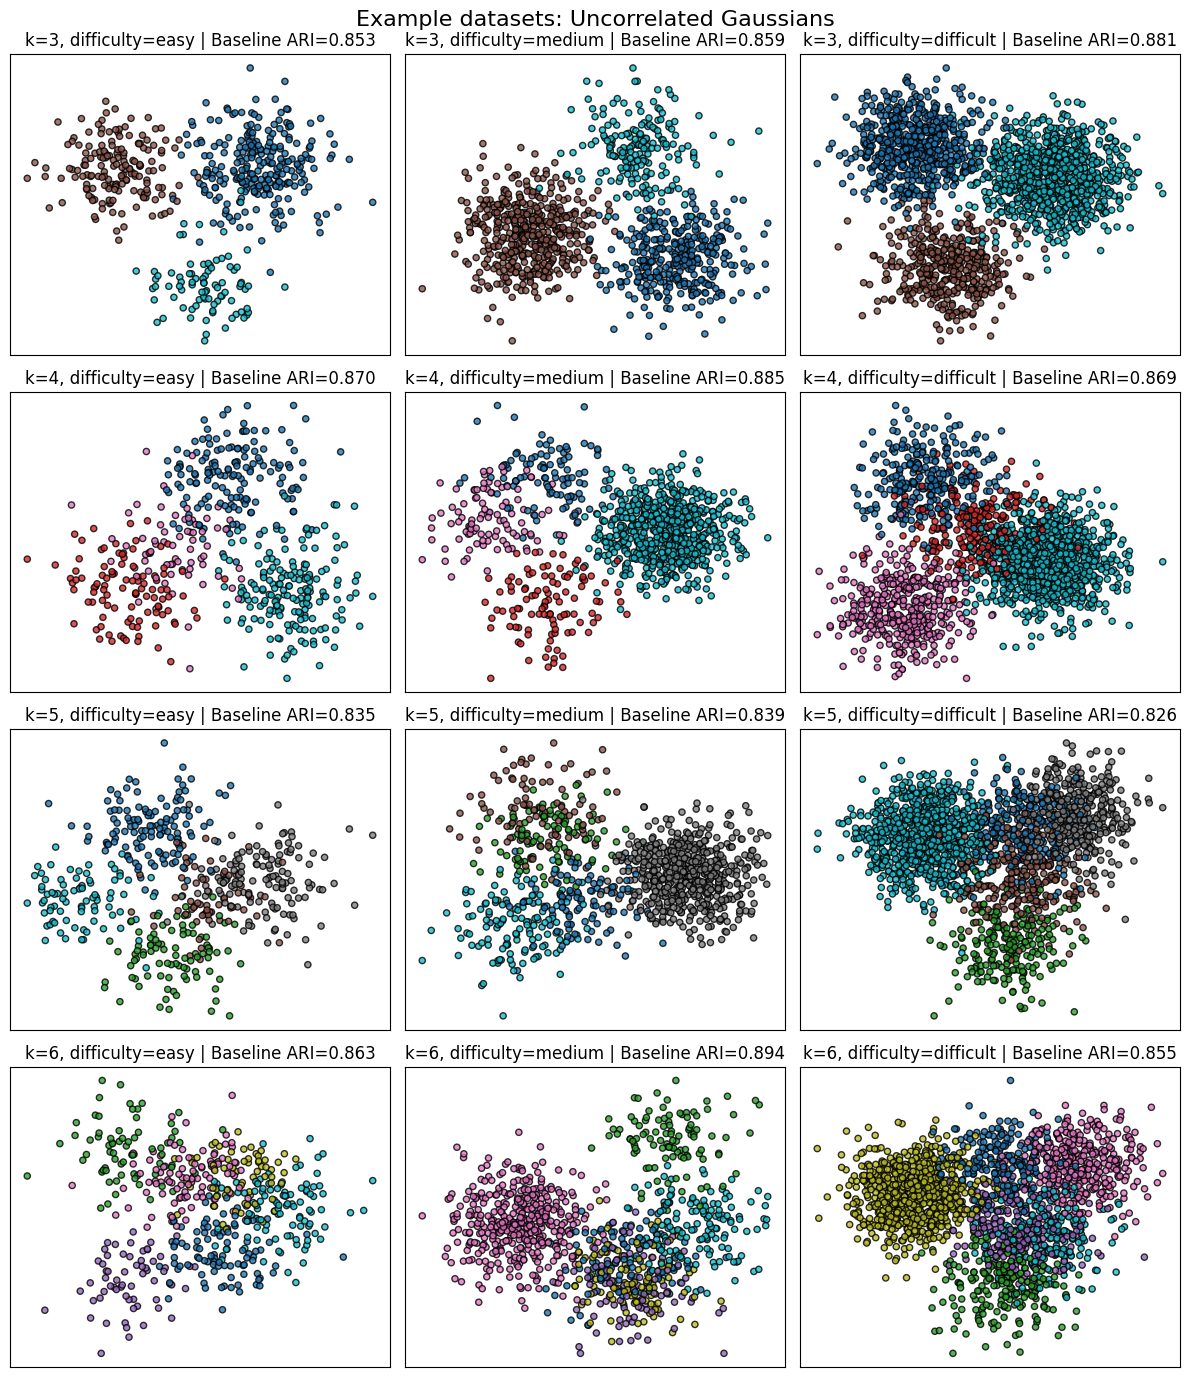

In [ ]:
B = 10
ks = [3, 4, 5, 6]
settings_by_k = settings_by_k_gausN
other_settings = other_settings_gausN
anchors = ['easy', 'medium', 'difficult']

fig, axes = plt.subplots(len(ks), len(anchors), figsize=(12, 14))
for i, k in enumerate(ks):
    for j, a in enumerate(anchors):
        X, y, _ = simulate_clusters(
            n_total=settings_by_k[k][a].get('n_total', 500),
            p=settings_by_k[k][a].get('p', 10),
            k=k,
            plotting=False,
            random_state=1*10 + j,
            # **settings_by_k[k][a],
            **{k: v for k, v in settings_by_k[k][a].items() if k not in ['p', 'n_total']},
            **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
        )
        
        ari_arr = []
        for b in range(B):
            X_val, y_val, _ = simulate_clusters(
                n_total=settings_by_k[k][a].get('n_total', 500),
                p=settings_by_k[k][a].get('p', 10),
                k=k,
                plotting=False,
                random_state=1*100 + j*10 + b,
                # **settings_by_k[k][a],
                **{k: v for k, v in settings_by_k[k][a].items() if k not in ['p', 'n_total']},
                **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
            )
            
            estimator = AgglomerativeClustering(
                n_clusters=k
            )
            y_hat_val = estimator.fit_predict(X_val)
            ari = adjusted_rand_score(y_val, y_hat_val)
            ari_arr.append(ari)
            
        ari_mean = np.mean(ari_arr)

        X_pca = PCA(n_components=2, random_state=0).fit_transform(X)
        ax = axes[i, j]
        ax.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=y, cmap="tab10", s=20, alpha=0.8, edgecolors="k"
        )
        ax.set_title(f"k={k}, difficulty={a} | Baseline ARI={ari_mean:.3f}")
        ax.set_xticks([]); ax.set_yticks([])
        
plt.suptitle("Example datasets: Uncorrelated Gaussians", fontsize=16)
plt.tight_layout(); plt.show()

In [ ]:
results_path = "../results/results_41.csv"

if not os.path.exists(results_path):
    results_41 = benchmark_cluster_metrics(
        settings_by_k_gausN,
        other_settings_gausN,
        B=20,
        model='agglomerative',
        external_metrics=["silhouette", 'gap'],
        random_state=42
    )
    
    os.makedirs("../results/", exist_ok=True)
    results_41.to_csv(results_path, index=False)
    
else:
    results_41 = pd.read_csv(results_path)

Benchmarking:   0%|          | 0/800 [00:00<?, ?it/s]

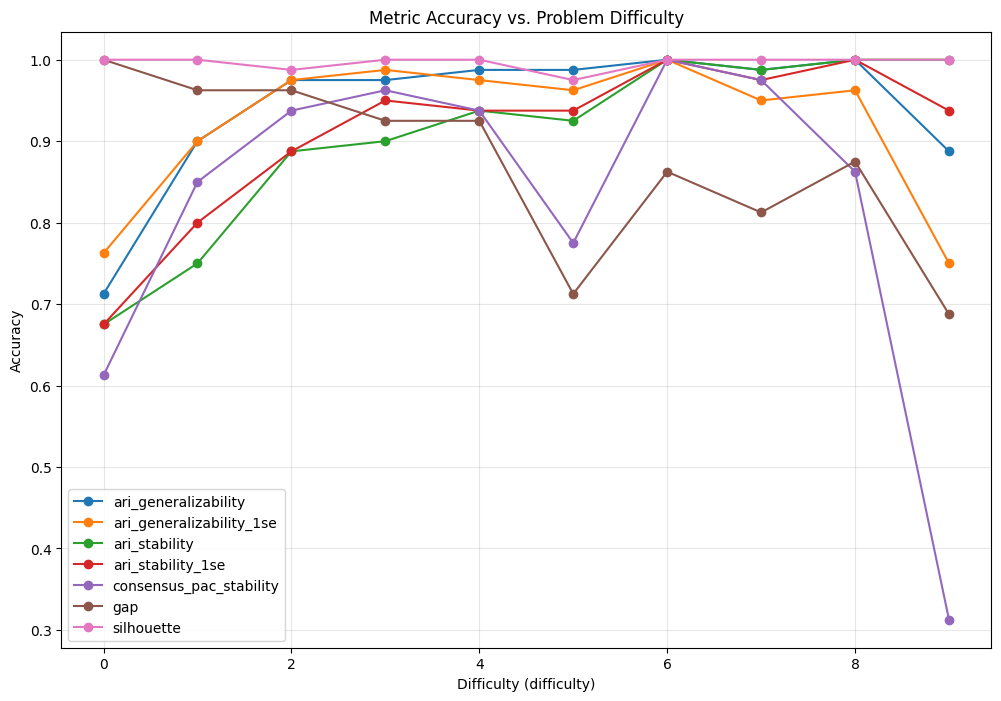

In [ ]:
plot_accuracy_vs_difficulty(results_41)

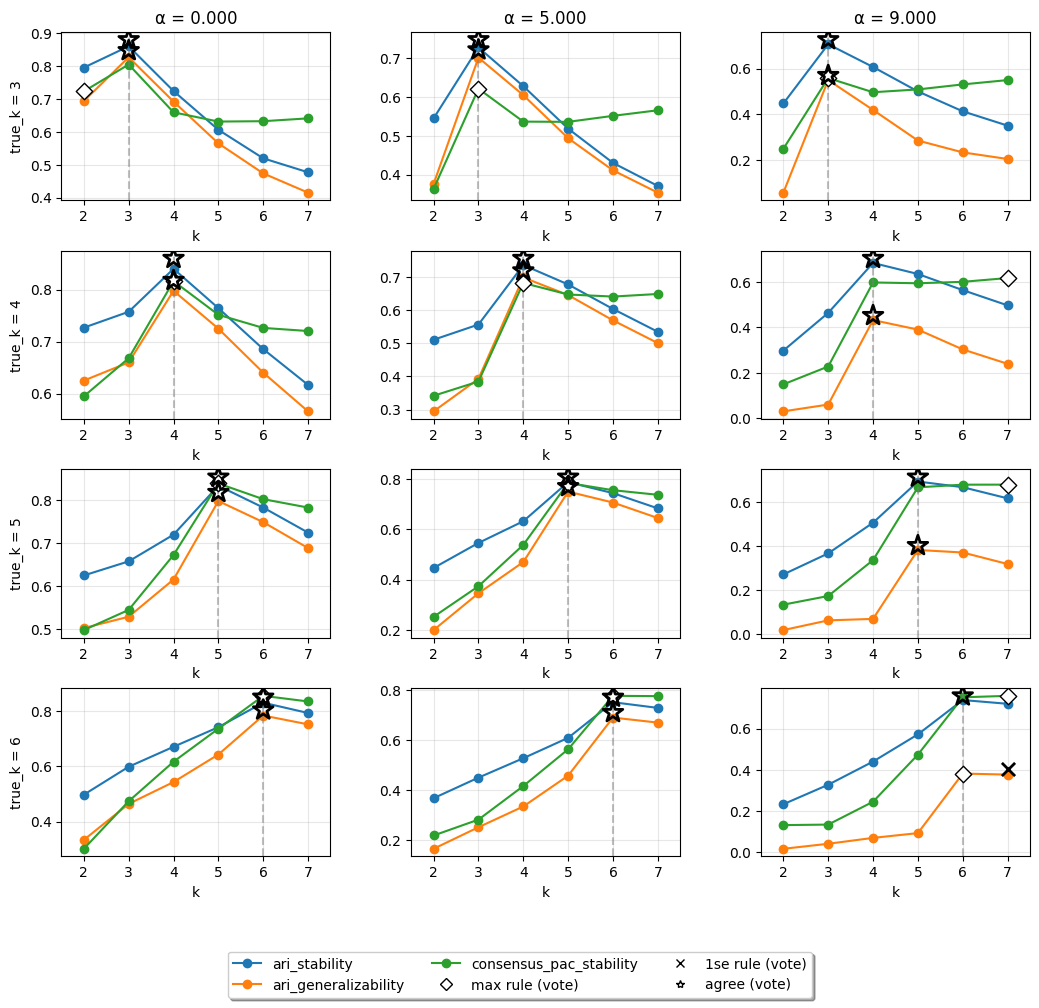

In [ ]:
plot_metric_lineplots_grid(results_41, range(10), metrics_to_display=['ari_stability', 'ari_generalizability', 'consensus_pac_stability'], show_majority_votes=True)

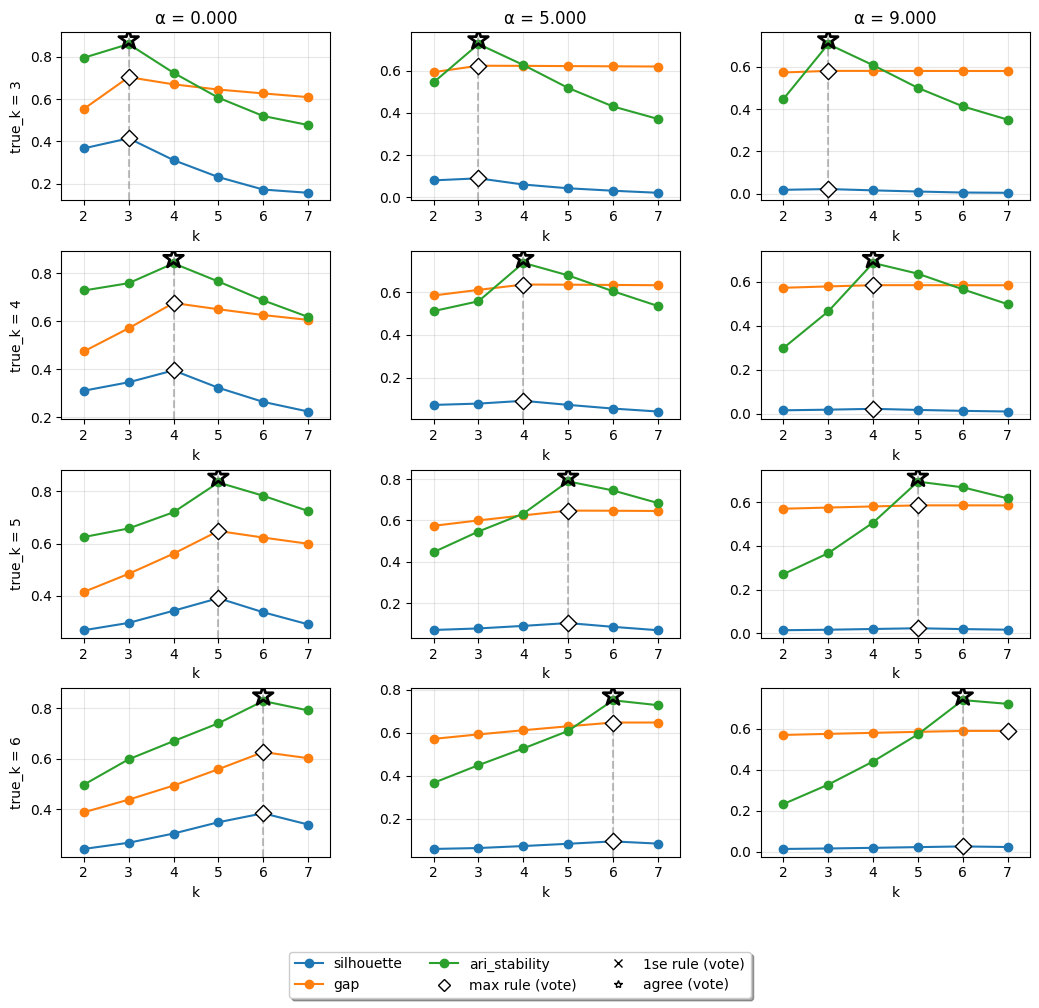

In [ ]:
plot_metric_lineplots_grid(results_41, range(10), metrics_to_display=['silhouette', 'gap', 'ari_stability'], show_majority_votes=True)

In [ ]:
print_summary_stats(results_41)


=== Accuracy (mean±std)
difficulty                           0             1             2             3             4             5             6             7             8  \
metric_name                                                                                                                                              
ari_generalizability       0.713±0.455   0.900±0.302   0.975±0.157   0.975±0.157   0.988±0.112  0.988±0.112*  1.000±0.000*   0.988±0.112  1.000±0.000*   
ari_generalizability_1se   0.762±0.428   0.900±0.302   0.975±0.157   0.988±0.112   0.975±0.157   0.963±0.191   1.000±0.000   0.950±0.219   0.963±0.191   
ari_stability              0.675±0.471   0.750±0.436   0.887±0.318   0.900±0.302   0.938±0.244   0.925±0.265   1.000±0.000   0.988±0.112   1.000±0.000   
ari_stability_1se          0.675±0.471   0.800±0.403   0.887±0.318   0.950±0.219   0.938±0.244   0.938±0.244   1.000±0.000   0.975±0.157   1.000±0.000   
consensus_pac_stability    0.613±0.490   0.850±0.35

---

### 4.2 Sample Size Benchmark Non-Linear:

In [36]:
settings_by_k_moonsN = {
    3: {
        'easy':         {"cluster_scale": [1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.375, 'center_box': 3.0, 'n_total': 500},
        'medium':       {"cluster_scale": [1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.375, 'center_box': 3.0, 'n_total': 1000},
        'difficult':    {"cluster_scale": [1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.375, 'center_box': 3.0, 'n_total': 2000},
    },
    4: {
        'easy':         {"cluster_scale": [1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.2, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 500},
        'medium':       {"cluster_scale": [1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.2, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 1000},
        'difficult':    {"cluster_scale": [1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.2, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 2000},
    },
    5: {
        'easy':         {"cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 500},
        'medium':       {"cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 1000},
        'difficult':    {"cluster_scale": [1.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 2000},
    },
    6: {
        'easy':         {"cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 500},
        'medium':       {"cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 1000},
        'difficult':    {"cluster_scale": [4.0, 2.0, 1.0, 1.0, 1.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'corr_strength': 0.5, 'embed_param': 0.38, 'center_box': 3.0, 'n_total': 2000},
    },
}

other_settings_moonsN = {
    "p": 8,
    "distribution": "moons",
    "balanced": False,
    "nonlinear": True,
    "embed_method": "random_fourier",
    "embed_dim": 32,
    "corr_type": "block",
    "block_size": 10
}

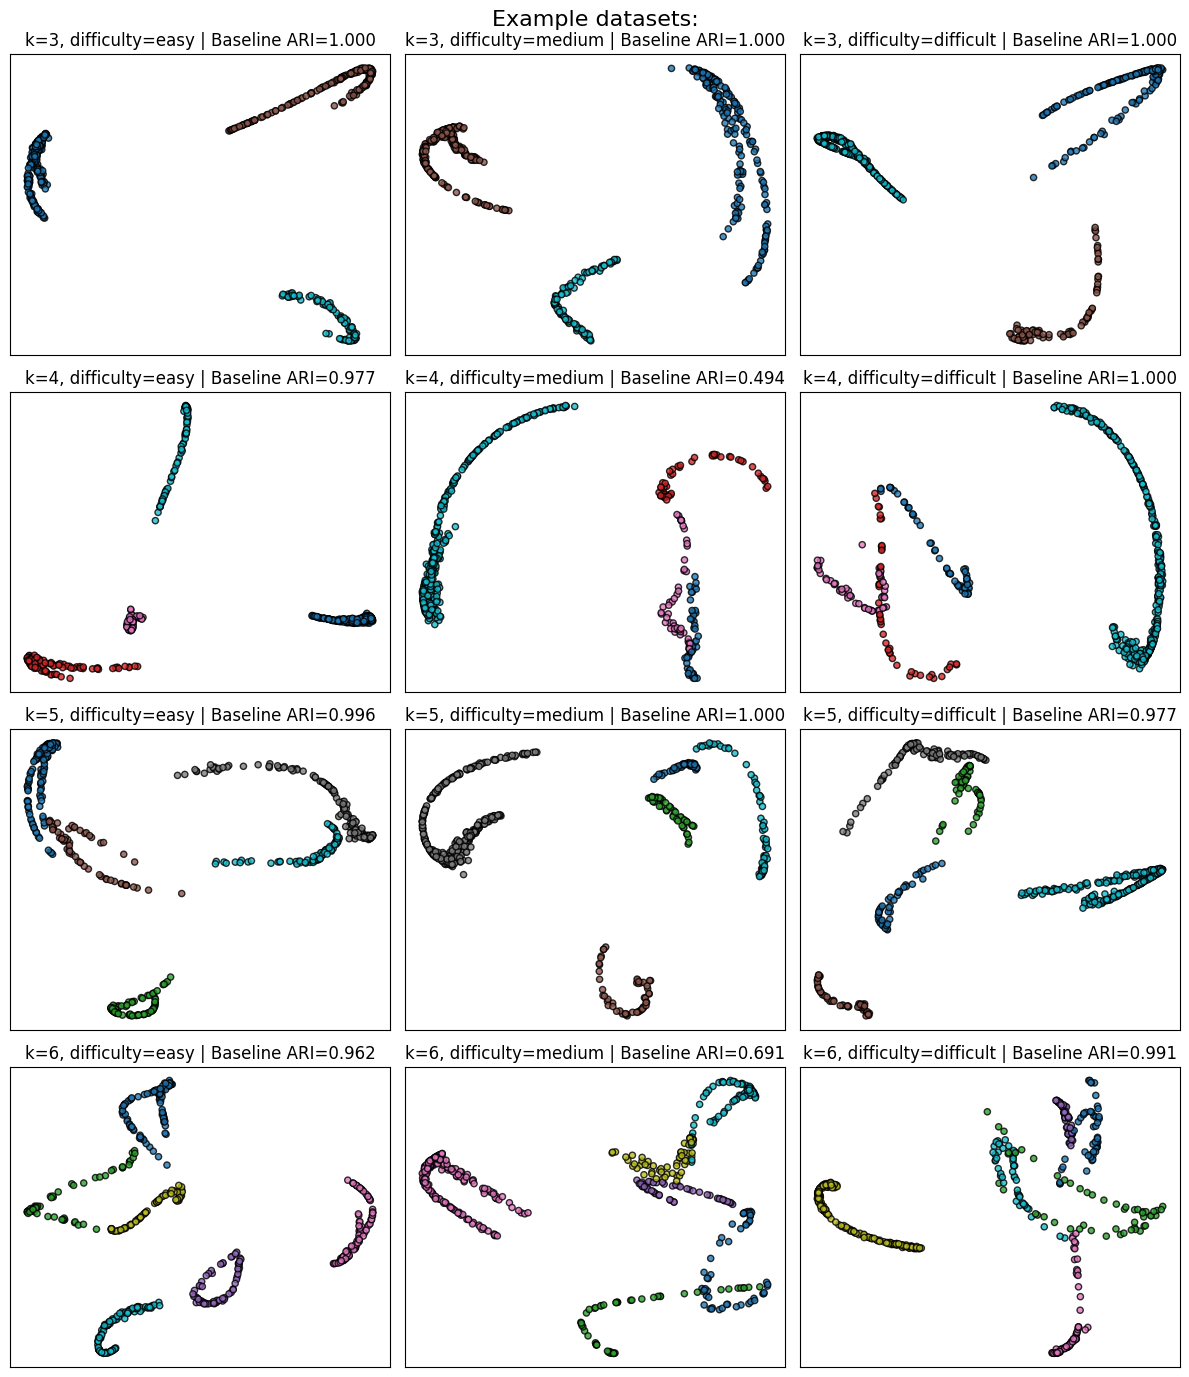

In [37]:
B = 20
ks = [3, 4, 5, 6]
settings_by_k = settings_by_k_moonsN
other_settings = other_settings_moonsN
anchors = ['easy', 'medium', 'difficult']

fig, axes = plt.subplots(len(ks), len(anchors), figsize=(12, 14))
for i, k in enumerate(ks):
    for j, a in enumerate(anchors):
        X, y, _ = simulate_clusters(
            n_total=other_settings.get('n_total', 500),
            p=settings_by_k[k][a].get('p', 10),
            k=k,
            plotting=False,
            random_state=1*10 + j,
            # **settings_by_k[k][a],
            **{k: v for k, v in settings_by_k[k][a].items() if k not in ['n_total', 'p']},
            **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
        )
        
        ari_arr = []
        for b in range(B):
            X_val, y_val, _ = simulate_clusters(
            n_total=settings_by_k[k][a].get('n_total', 500),
            p=other_settings.get('p', 10),
            k=k,
            plotting=False,
            random_state=1*10 + j,
            # **settings_by_k[k][a],
            **{k: v for k, v in settings_by_k[k][a].items() if k not in ['n_total','p']},
            **{k: v for k, v in other_settings.items() if k not in ['n_total', 'p', 'plotting']}
        )
            
            estimator = SpectralClustering(
                n_clusters=k,
                affinity="rbf", 
                gamma=gamma_quantiles(X_val)[3],
                random_state=b
            )
            y_hat_val = estimator.fit_predict(X_val)
            ari = adjusted_rand_score(y_val, y_hat_val)
            ari_arr.append(ari)
            
        ari_mean = np.mean(ari_arr)

        X_pca = PCA(n_components=2, random_state=0).fit_transform(X)
        ax = axes[i, j]
        ax.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=y, cmap="tab10", s=20, alpha=0.8, edgecolors="k"
        )
        ax.set_title(f"k={k}, difficulty={a} | Baseline ARI={ari_mean:.3f}")
        ax.set_xticks([]); ax.set_yticks([])
        
plt.suptitle("Example datasets:", fontsize=16)
plt.tight_layout(); plt.show()

In [ ]:
results_path = "../results/results_42.csv"

if not os.path.exists(results_path):
    results_42 = benchmark_cluster_metrics(
        settings_by_k_moonsN,
        other_settings_moonsN,
        B=20,
        model='spectral',
        external_metrics=["silhouette", 'gap'],
        random_state=42
    )
    
    os.makedirs("../results/", exist_ok=True)
    results_42.to_csv(results_path, index=False)
    
else:
    results_42 = pd.read_csv(results_path)

Benchmarking:   0%|          | 0/800 [00:00<?, ?it/s]

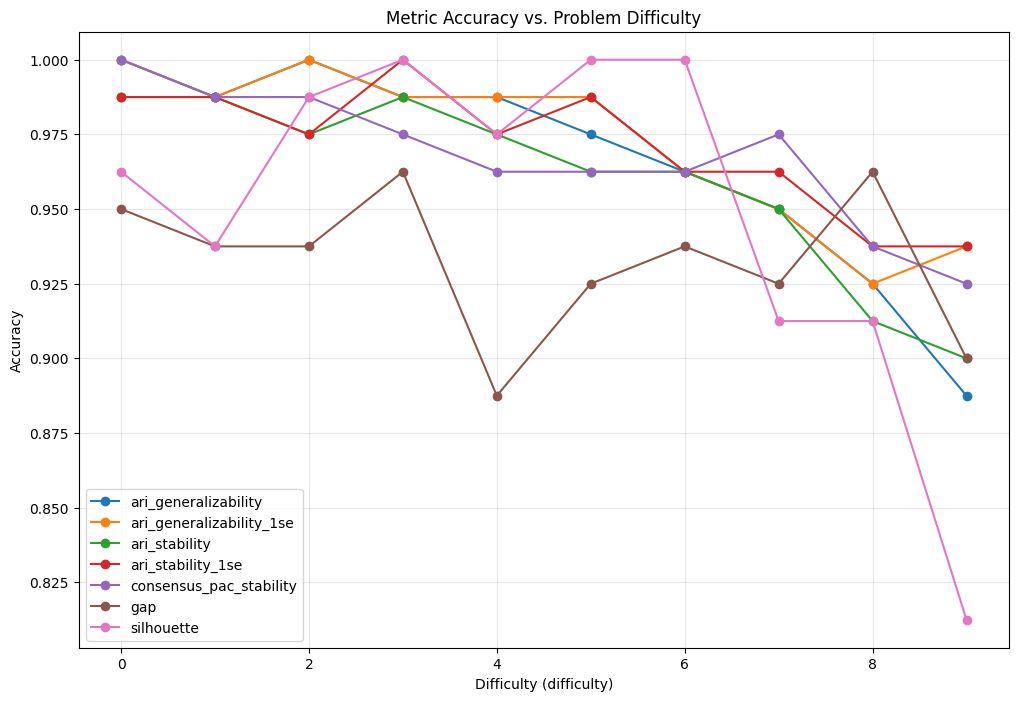

In [ ]:
plot_accuracy_vs_difficulty(results_42)

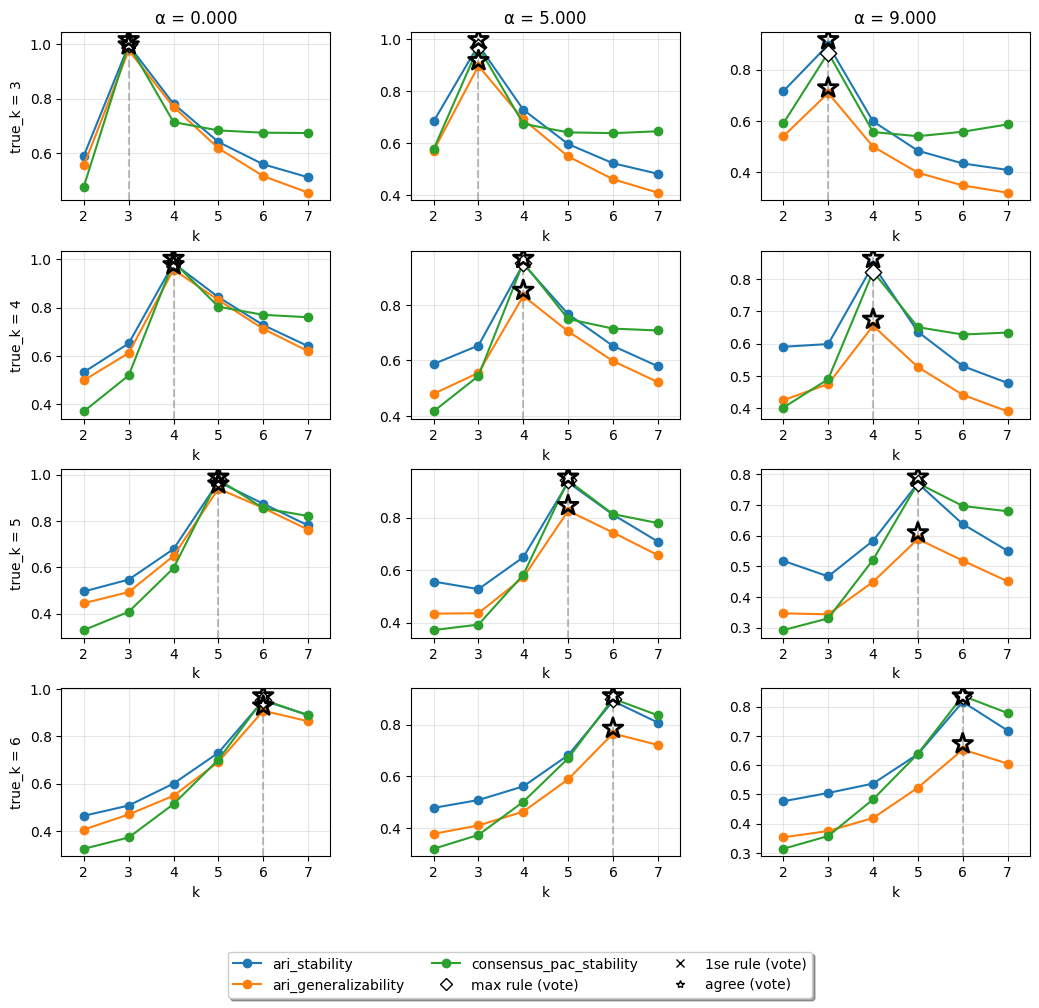

In [ ]:
plot_metric_lineplots_grid(results_42, range(10), metrics_to_display=['ari_stability', 'ari_generalizability', 'consensus_pac_stability'], show_majority_votes=True)

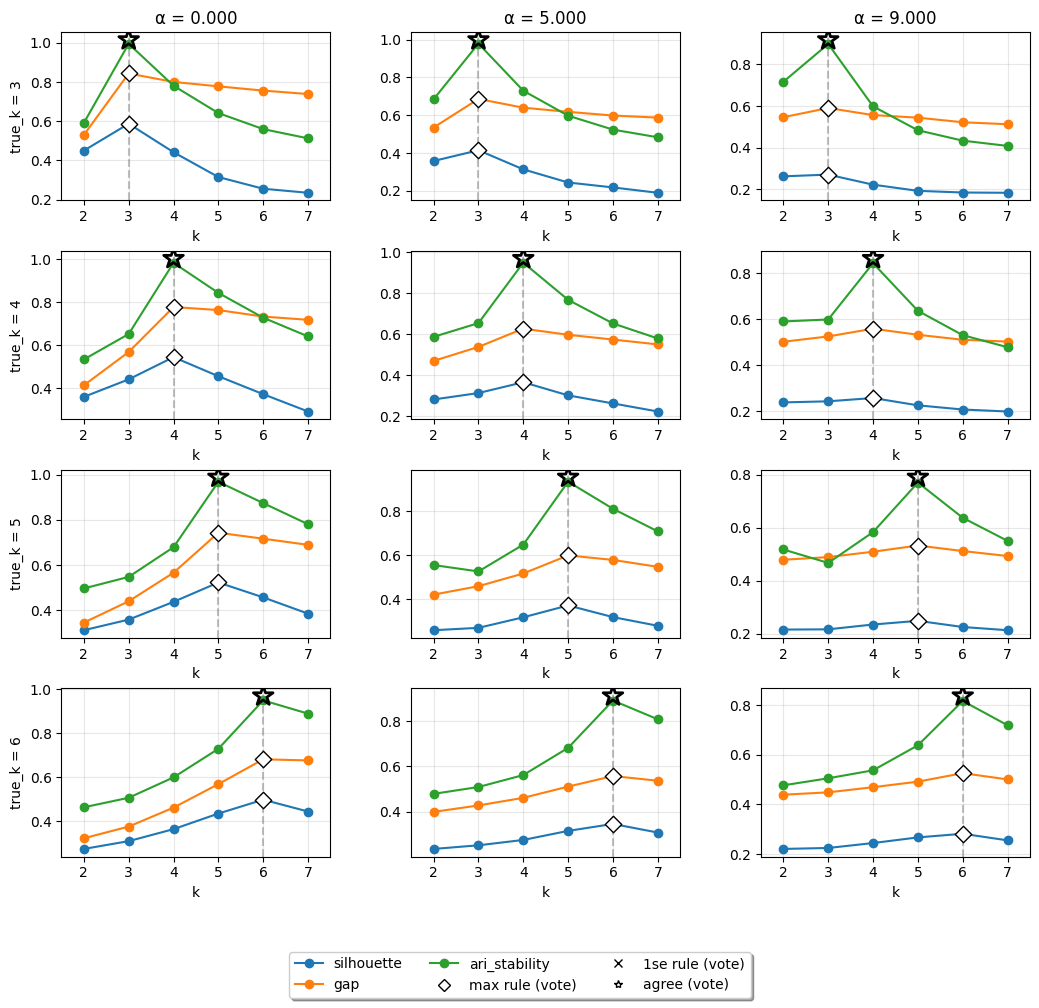

In [ ]:
plot_metric_lineplots_grid(results_42, range(10), metrics_to_display=['silhouette', 'gap', 'ari_stability'], show_majority_votes=True)

In [ ]:
print_summary_stats(results_42)


=== Accuracy (mean±std)
difficulty                           0             1             2             3             4             5             6             7             8  \
metric_name                                                                                                                                              
ari_generalizability      1.000±0.000*  0.988±0.112*  1.000±0.000*   0.988±0.112  0.988±0.112*   0.975±0.157   0.963±0.191   0.950±0.219   0.925±0.265   
ari_generalizability_1se   1.000±0.000   0.988±0.112   1.000±0.000   0.988±0.112   0.988±0.112   0.988±0.112   0.963±0.191   0.950±0.219   0.925±0.265   
ari_stability              0.988±0.112   0.988±0.112   0.975±0.157   0.988±0.112   0.975±0.157   0.963±0.191   0.963±0.191   0.950±0.219   0.912±0.284   
ari_stability_1se          0.988±0.112   0.988±0.112   0.975±0.157  1.000±0.000*   0.975±0.157   0.988±0.112   0.963±0.191   0.963±0.191   0.938±0.244   
consensus_pac_stability    1.000±0.000   0.988±0.11

---